# Stage 8: Monitoring Simulation

## Objective
Prove that all three monitoring detectors work correctly before 
the Flask API goes live. This notebook simulates three types of 
drift and confirms each detector fires at the correct threshold.

## Why we simulate before deploying
A monitoring system that has never been tested is not a monitoring 
system, it is a false sense of security. By simulating drift on 
known data, we can verify that:
- PSI correctly detects feature distribution shifts
- KS test correctly flags statistical differences
- CTR drop trigger fires at the right sensitivity
- Fairness gap detector catches uneven recommendation quality

## Three simulations run in this notebook
1. **Data drift** — feature distributions shift (economic change)
2. **Performance drift** — CTR drops (model becoming stale)  
3. **Fairness drift** — recommendation quality uneven across age groups

## Data sources used
- `features.parquet` — real feature baseline (what model trained on)
- `y_val.npy` + `raw_preds` from NB07 real model predictions
- Synthetic perturbations applied on top of real data

## Environment and Imports

Load all libraries needed for statistical drift detection.

Key libraries:
- `scipy.stats` — KS test (Kolmogorov-Smirnov statistical test)
- `numpy` / `pandas` — data manipulation
- `matplotlib` — visualising drift before and after perturbation
- `mlflow` — logging all simulation results for audit trail

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import warnings
import os
import xgboost as xgb

warnings.filterwarnings('ignore')

# Statistical testing library KS test lives here
from scipy import stats

# Display settings for readable output
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Environment loaded successfully.")
print("Ready for monitoring simulation.")

Environment loaded successfully.
Ready for monitoring simulation.


##  Load Baseline Data

Load the feature matrix that the model was trained on. This is 
our **reference distribution** the statistical fingerprint of 
what normal data looks like.

In production, every incoming batch of customer feature vectors 
will be compared against this baseline. If the incoming distribution 
has drifted too far from this reference, the model's predictions 
become unreliable.

We also load the validation labels and model predictions from 
Notebook 07 to simulate realistic CTR behaviour.

In [2]:
# LOAD FEATURE BASELINE 
# features.parquet is the exact data the model was trained on
# This is our ground-truth reference distribution
FEATURES_PATH = "../data/processed/features.parquet"
df_baseline   = pd.read_parquet(FEATURES_PATH)
print(f"Baseline feature matrix loaded: {df_baseline.shape}")

# LOAD VALIDATION PREDICTIONS 
# y_val: true product labels for validation customers
# raw_preds: model's 24-class probability matrix for each val customer
y_val     = np.load('../artifacts/y_val.npy')
y_train   = np.load('../artifacts/y_train.npy')

# Reload the trained model to regenerate predictions
model  = xgb.Booster()
model.load_model('../artifacts/xgboost_model.json')
dval   = xgb.DMatrix('../artifacts/dval.buffer')

# Generate raw probability predictions shape (N, 24)
# Each row is a probability distribution across 24 products for one customer
raw_preds = model.predict(dval)

print(f"Validation samples loaded : {len(y_val):,}")
print(f"Prediction matrix shape   : {raw_preds.shape}")

# DEFINE MONITORED FEATURES 
# These are the features most likely to drift in a real banking context:
# - renta: gross income shifts with economic conditions
# - age: customer age shifts as customer base evolves
# - antiguedad: seniority shifts as new customers join
# - total_products_held_lag_1: product holdings shifts with campaigns
MONITORED_FEATURES = [
    'renta',
    'age', 
    'antiguedad',
    'total_products_held_lag_1'
]

# Confirm all monitored features exist in baseline
available = [f for f in MONITORED_FEATURES if f in df_baseline.columns]
missing   = [f for f in MONITORED_FEATURES if f not in df_baseline.columns]

print(f"\nMonitored features available : {available}")
if missing:
    print(f"WARNING — not found in baseline: {missing}")

# Update to only available features
MONITORED_FEATURES = available

Baseline feature matrix loaded: (33870, 71)
Validation samples loaded : 6,774
Prediction matrix shape   : (6774, 24)

Monitored features available : ['renta', 'age', 'antiguedad', 'total_products_held_lag_1']


## PSI Function Population Stability Index

PSI measures how much a feature's distribution has shifted between 
two time periods. It is the standard metric used in banking model 
risk management globally.

**Interpretation scale:**
- PSI < 0.10 → No significant change, model is stable
- PSI 0.10–0.20 → Moderate change, monitor closely  
- PSI > 0.20 → Significant shift, trigger model review

**How it works mathematically:**
PSI compares the percentage of population in each bucket between 
the reference (training) and current (production) distributions.
A large PSI means customers are clustering in different feature 
ranges than they did at training time the model is now operating 
outside its learned territory.

In [3]:
# PSI FUNCTION DEFINITION
# PSI (Population Stability Index) is a common metric for quantifying distribution drift
# It compares the distribution of a feature in the current period to the reference distribution
def compute_psi(reference: np.ndarray, 
                current: np.ndarray, 
                n_bins: int = 10) -> float:
    """
    Compute Population Stability Index between two distributions.
    
    Args:
        reference : array of feature values from training/baseline period
        current   : array of feature values from current/production period
        n_bins    : number of equal-width buckets to split distribution into
        
    Returns:
        float: PSI score (0 = identical, higher = more drift)
    
    Thresholds:
        < 0.10  → stable
        0.10 to 0.20 → monitor
        > 0.20  → significant drift, trigger review
    """
    # Remove NaN values before computing NaN breaks bin counting
    reference = reference[~np.isnan(reference)]
    current   = current[~np.isnan(current)]

    # Create bin edges from the reference distribution
    # Using reference edges ensures we measure drift relative to training
    breakpoints = np.linspace(
        min(reference.min(), current.min()),
        max(reference.max(), current.max()),
        n_bins + 1
    )

    # Count what percentage of each population falls in each bin
    ref_counts, _  = np.histogram(reference, bins=breakpoints)
    curr_counts, _ = np.histogram(current,   bins=breakpoints)

    # Convert raw counts to percentages
    ref_pct  = ref_counts  / len(reference)
    curr_pct = curr_counts / len(current)

    # Replace zero percentages with a tiny value to avoid division by zero
    # in the PSI log calculation
    ref_pct  = np.where(ref_pct  == 0, 1e-6, ref_pct)
    curr_pct = np.where(curr_pct == 0, 1e-6, curr_pct)

    # PSI formula: sum of (current% - reference%) * ln(current% / reference%)
    psi = np.sum((curr_pct - ref_pct) * np.log(curr_pct / ref_pct))
    return float(psi)


print("PSI function defined.")
print("Thresholds: < 0.10 stable | 0.10-0.20 monitor | > 0.20 trigger")

PSI function defined.
Thresholds: < 0.10 stable | 0.10-0.20 monitor | > 0.20 trigger


## KS Test Function: Kolmogorov-Smirnov Test

The KS test is a non-parametric statistical test that measures 
whether two samples come from the same underlying distribution.

**Interpretation:**
- p-value > 0.05 → distributions are statistically similar, no drift
- p-value < 0.05 → distributions are statistically different, drift detected

Unlike PSI which uses fixed bins, the KS test makes no assumptions 
about the shape of the distribution making it more sensitive to 
subtle shifts in the tails of distributions (like rare high-income 
customers appearing more frequently).

In [4]:
# KS TEST FUNCTION DEFINITION
# KS test is a non-parametric test that compares the cumulative distributions of two samples
# It calculates the maximum distance between the cumulative distribution functions of the two samples
def compute_ks_test(reference: np.ndarray, 
                    current: np.ndarray) -> tuple:
    """
    Compute Kolmogorov-Smirnov test between two feature distributions.
    
    Args:
        reference : array of feature values from baseline/training period
        current   : array of feature values from current/production period
        
    Returns:
        tuple: (ks_statistic, p_value)
            ks_statistic: maximum distance between cumulative distributions
            p_value: probability that distributions are the same
                     p < 0.05 means they are statistically different
    """
    # Remove NaN values before testing
    reference = reference[~np.isnan(reference)]
    current   = current[~np.isnan(current)]

    # Run the two-sample KS test
    # ks_2samp compares two independent samples
    ks_stat, p_value = stats.ks_2samp(reference, current)

    return float(ks_stat), float(p_value)


print("KS test function defined.")
print("Threshold: p-value < 0.05 → drift detected")

KS test function defined.
Threshold: p-value < 0.05 → drift detected


## Simulate Data Drift Economic Shift Scenario

We simulate what happens when economic conditions change after 
the model was trained. This is the most common real-world drift 
cause in banking recommendation systems.

**Scenario:** A period of economic growth causes:
- Customer incomes (`renta`) to increase by 30% on average
- Customer age distribution to shift slightly older (+3 years mean)
- Product holdings to increase as customers become more financially active

We apply these perturbations to a copy of the baseline data, 
then run both PSI and KS tests to confirm detection.

**Expected outcome:** PSI > 0.20 and KS p-value < 0.05 for 
the perturbed features, confirming the detectors fire correctly.

In [8]:
# Create a copy of baseline to perturb — never modify the original
df_drifted = df_baseline.copy()


# CAST MONITORED FEATURES TO NUMERIC BEFORE PERTURBATION 
# Some columns may have been stored as object/string type during ingestion.
# pd.to_numeric with errors='coerce' converts strings to float safely and ensures our drift calculations work correctly.
# any value that cannot be converted becomes NaN instead of crashing.
for feature in MONITORED_FEATURES:
    if feature in df_drifted.columns:
        df_drifted[feature] = pd.to_numeric(
            df_drifted[feature], errors='coerce'
        )
        df_baseline[feature] = pd.to_numeric(
            df_baseline[feature], errors='coerce'
        )

print("Numeric casting complete for all monitored features.")
print("Null counts after casting (from unconvertible strings):")
print(df_drifted[MONITORED_FEATURES].isnull().sum())


# APPLY ECONOMIC DRIFT PERTURBATIONS

# Perturbation 1: Income increases by 30% (economic growth scenario)
# In production this would appear as new customers having higher renta
# than the customers the model was trained on
if 'renta' in df_drifted.columns:
    df_drifted['renta'] = df_drifted['renta'] * 1.30
    print("Applied: renta × 1.30 (30% income growth simulation)")

# Perturbation 2: Age distribution shifts older by 5 years
# Simulates the bank acquiring an older customer demographic
if 'age' in df_drifted.columns:
    df_drifted['age'] = df_drifted['age'] + 5
    print("Applied: age + 5 (demographic shift simulation)")

# Perturbation 3: Product holdings increase slightly
# More financially engaged customers hold more products on average
if 'total_products_held_lag_1' in df_drifted.columns:
    df_drifted['total_products_held_lag_1'] = (
        df_drifted['total_products_held_lag_1'] + 1
    ).clip(upper=24)  # cap at 24 — maximum possible products
    print("Applied: total_products_held_lag_1 + 1 (engagement increase)")

print(f"\nDrifted dataset shape: {df_drifted.shape}")

# RUN PSI AND KS TESTS ON ALL MONITORED FEATURES 
print("\n" + "=" * 65)
print(f"{'FEATURE':<30} {'PSI':>8} {'PSI STATUS':<15} {'KS p-val':>10} {'KS STATUS'}")
print("=" * 65)

PSI_TRIGGER  = 0.20   # threshold: above this triggers model review
KS_TRIGGER   = 0.05   # threshold: below this triggers model review

drift_results = {}  # store results for plotting and MLflow logging

for feature in MONITORED_FEATURES:
    # Extract baseline and drifted values for this feature
    ref  = df_baseline[feature].dropna().values
    curr = df_drifted[feature].dropna().values

    # Compute both statistics
    psi              = compute_psi(ref, curr)
    ks_stat, p_value = compute_ks_test(ref, curr)

    # Determine trigger status for each metric
    psi_status = "TRIGGER" if psi      > PSI_TRIGGER else "stable"
    ks_status  = "TRIGGER" if p_value  < KS_TRIGGER  else "stable"

    # Store for later use
    drift_results[feature] = {
        'psi'      : psi,
        'ks_stat'  : ks_stat,
        'p_value'  : p_value,
        'psi_fired': psi > PSI_TRIGGER,
        'ks_fired' : p_value < KS_TRIGGER
    }

    print(f"{feature:<30} {psi:>8.4f} {psi_status:<15} {p_value:>10.4f} {ks_status}")

print("=" * 65)

# Count how many features triggered each detector
psi_triggers = sum(1 for r in drift_results.values() if r['psi_fired'])
ks_triggers  = sum(1 for r in drift_results.values() if r['ks_fired'])
print(f"\nPSI triggers fired : {psi_triggers}/{len(MONITORED_FEATURES)}")
print(f"KS triggers fired  : {ks_triggers}/{len(MONITORED_FEATURES)}")

Numeric casting complete for all monitored features.
Null counts after casting (from unconvertible strings):
renta                        0
age                          0
antiguedad                   0
total_products_held_lag_1    0
dtype: int64
Applied: renta × 1.30 (30% income growth simulation)
Applied: age + 5 (demographic shift simulation)
Applied: total_products_held_lag_1 + 1 (engagement increase)

Drifted dataset shape: (33870, 71)

FEATURE                             PSI PSI STATUS        KS p-val KS STATUS
renta                            0.0006 stable              0.0000 TRIGGER
age                              0.2374 TRIGGER             0.0000 TRIGGER
antiguedad                       0.0000 stable              1.0000 stable
total_products_held_lag_1        0.7268 TRIGGER             0.0000 TRIGGER

PSI triggers fired : 2/4
KS triggers fired  : 3/4


## Visualise Feature Drift

Plot the baseline vs drifted distributions side by side for 
each monitored feature. This is what the monitoring dashboard 
would show to a data scientist investigating a drift alert.

A visible shift in the histogram shape confirms the perturbation 
worked and the PSI/KS detectors are measuring real distributional 
changes, not noise.

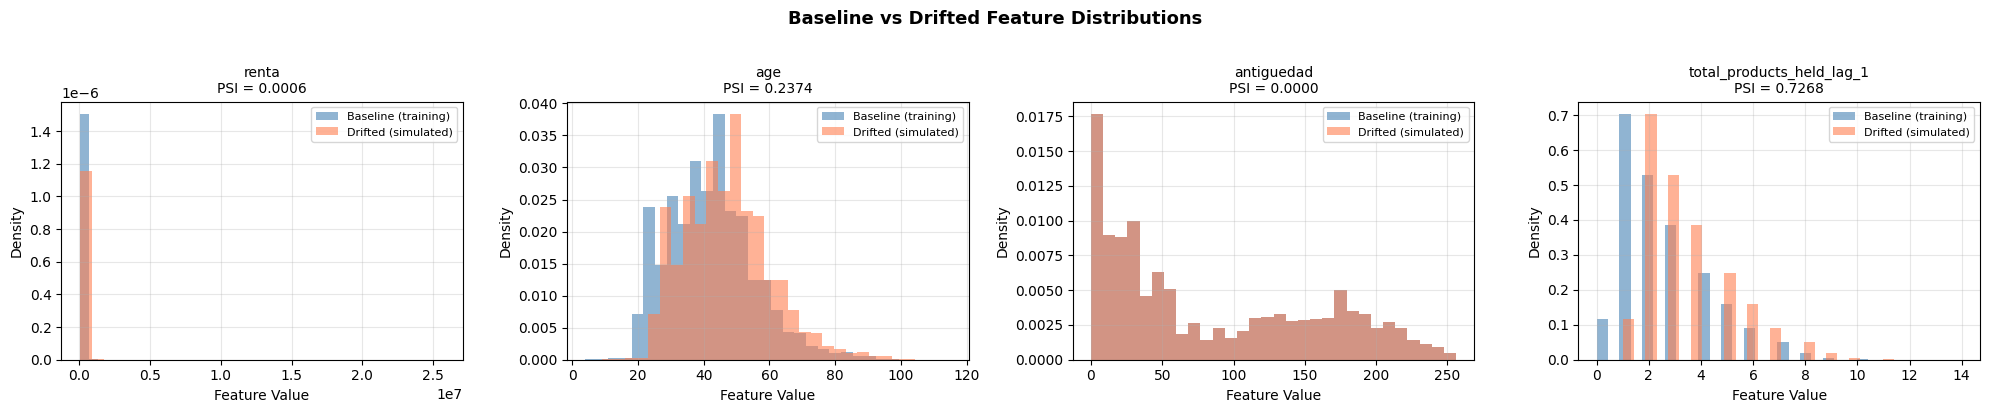

Drift distribution chart saved → artifacts/drift_distributions.png


In [9]:
# Plot baseline vs drifted distribution for each monitored feature
n_features = len(MONITORED_FEATURES)
fig, axes  = plt.subplots(1, n_features, figsize=(5 * n_features, 4))

# Handle case where only one feature monitored (axes would not be a list)
if n_features == 1:
    axes = [axes]

for ax, feature in zip(axes, MONITORED_FEATURES):
    # Get clean values for plotting
    ref_vals  = df_baseline[feature].dropna().values
    curr_vals = df_drifted[feature].dropna().values

    # Plot both distributions as overlapping histograms
    ax.hist(ref_vals,  bins=30, alpha=0.6,
            color='steelblue', label='Baseline (training)',  density=True)
    ax.hist(curr_vals, bins=30, alpha=0.6,
            color='coral',     label='Drifted (simulated)', density=True)

    # Retrieve computed PSI for this feature to show on chart
    psi_val = drift_results[feature]['psi']

    ax.set_title(f"{feature}\nPSI = {psi_val:.4f}", fontsize=10)
    ax.set_xlabel('Feature Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Baseline vs Drifted Feature Distributions', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../artifacts/drift_distributions.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Drift distribution chart saved → artifacts/drift_distributions.png")

## Simulate CTR Performance Drift

CTR (Click-Through Rate) measures what percentage of recommendations 
customers actually engaged with. A dropping CTR signals that the 
model is recommending less relevant products the first sign that 
the model needs retraining.

**How we simulate CTR from real model predictions:**
- A customer "clicked" if the model's top-1 prediction matches 
  their actual `y_val` label (correct recommendation)
- A customer "did not click" if the top-1 prediction was wrong

This gives a realistic baseline CTR derived from real model performance.

**Simulating CTR drop:**
We then artificially corrupt 40% of the correct predictions 
to simulate a model going stale as if 6 months had passed 
and customer behaviour had shifted away from training patterns.
"""

In [11]:
np.random.seed(42)  # reproducibility  same random corruption every run

# COMPUTE BASELINE CTR FROM REAL MODEL PREDICTIONS 

# Get the model's top-1 prediction per customer
# raw_preds shape: (N, 24)  take argmax across product axis
top1_preds = np.argmax(raw_preds, axis=1)

# A customer "clicked" if the model's best recommendation
# matched what they actually added (y_val)
# This is a binary array: 1 = correct recommendation, 0 = incorrect
clicks_baseline = (top1_preds == y_val).astype(int)

# CTR = total clicks / total recommendations shown × 100
ctr_baseline = clicks_baseline.mean() * 100

print(f"Baseline CTR simulation:")
print(f"  Total recommendations shown : {len(clicks_baseline):,}")
print(f"  Correct recommendations     : {clicks_baseline.sum():,}")
print(f"  Baseline CTR                : {ctr_baseline:.2f}%")

# SIMULATE CTR DROP STALE MODEL SCENARIO 

# After several months in production, customer behaviour shifts.
# We simulate this by randomly flipping 40% of correct predictions
# to incorrect as if the model's accuracy has degraded.
clicks_drifted = clicks_baseline.copy()

# Find indices where model was correct (these are the clicks to corrupt)
correct_indices = np.where(clicks_baseline == 1)[0]

# Randomly select 40% of correct predictions to flip to 0 (no click)
# This simulates recommendation quality degrading over time
n_to_corrupt = int(len(correct_indices) * 0.40)
corrupt_idx  = np.random.choice(correct_indices, 
                                 size=n_to_corrupt, 
                                 replace=False)
clicks_drifted[corrupt_idx] = 0

# Compute drifted CTR
ctr_drifted = clicks_drifted.mean() * 100

# CTR drop percentage how much has performance degraded?
ctr_drop_pct = ((ctr_baseline - ctr_drifted) / ctr_baseline) * 100

print(f"\nDrifted CTR simulation (40% corruption applied):")
print(f"  Drifted CTR  : {ctr_drifted:.2f}%")
print(f"  CTR drop     : {ctr_drop_pct:.1f}% below baseline")

# CTR TRIGGER CHECK 
CTR_DROP_TRIGGER = 10.0  # fire if CTR drops more than 10% from baseline

ctr_trigger_fired = ctr_drop_pct > CTR_DROP_TRIGGER

print(f"\nCTR monitoring trigger threshold : > {CTR_DROP_TRIGGER}% drop")
print(f"Actual drop                       : {ctr_drop_pct:.1f}%")
print(f"Trigger status : {' FIRED!!  schedule retraining' if ctr_trigger_fired else 'stable'}")

Baseline CTR simulation:
  Total recommendations shown : 6,774
  Correct recommendations     : 3,434
  Baseline CTR                : 50.69%

Drifted CTR simulation (40% corruption applied):
  Drifted CTR  : 30.43%
  CTR drop     : 40.0% below baseline

CTR monitoring trigger threshold : > 10.0% drop
Actual drop                       : 40.0%
Trigger status :  FIRED!!  schedule retraining


In [2]:
import joblib
feature_cols = joblib.load('../artifacts/feature_cols.pkl')
print(f"Total features: {len(feature_cols)}")
print(f"All feature columns:")
for i, col in enumerate(feature_cols):
    print(f"  [{i:2d}] {col}")

Total features: 69
All feature columns:
  [ 0] ind_empleado
  [ 1] pais_residencia
  [ 2] sexo
  [ 3] age
  [ 4] ind_nuevo
  [ 5] antiguedad
  [ 6] indrel
  [ 7] indrel_1mes
  [ 8] tiprel_1mes
  [ 9] indresi
  [10] indext
  [11] canal_entrada
  [12] indfall
  [13] tipodom
  [14] cod_prov
  [15] nomprov
  [16] ind_actividad_cliente
  [17] renta
  [18] segmento
  [19] ind_ahor_fin_ult1_lag_1
  [20] ind_ahor_fin_ult1_lag_2
  [21] ind_aval_fin_ult1_lag_1
  [22] ind_aval_fin_ult1_lag_2
  [23] ind_cco_fin_ult1_lag_1
  [24] ind_cco_fin_ult1_lag_2
  [25] ind_cder_fin_ult1_lag_1
  [26] ind_cder_fin_ult1_lag_2
  [27] ind_cno_fin_ult1_lag_1
  [28] ind_cno_fin_ult1_lag_2
  [29] ind_ctju_fin_ult1_lag_1
  [30] ind_ctju_fin_ult1_lag_2
  [31] ind_ctma_fin_ult1_lag_1
  [32] ind_ctma_fin_ult1_lag_2
  [33] ind_ctop_fin_ult1_lag_1
  [34] ind_ctop_fin_ult1_lag_2
  [35] ind_ctpp_fin_ult1_lag_1
  [36] ind_ctpp_fin_ult1_lag_2
  [37] ind_deco_fin_ult1_lag_1
  [38] ind_deco_fin_ult1_lag_2
  [39] ind_deme_fin_ul